In [1]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

sim_name = "i70-surfaceattached-multiple"

path_top = f"simulations/{sim_name}/runtime/top.pdb"
path_tra = f"simulations/{sim_name}/runtime/{sim_name}.dcd"
u = mda.Universe(path_top, path_tra)

def get_pos_of_resn(res_n):
    positions = []

    for ts in u.trajectory:
        last_res = u.residues[res_n].atoms.select_atoms("name CA")
        positions.append(last_res.positions[0])

    return np.array(positions)

/Users/boraciner/Developer/ELP-Simulations/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/boraciner/Developer/ELP-Simulations/.venv/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


(0.0, 500.0)

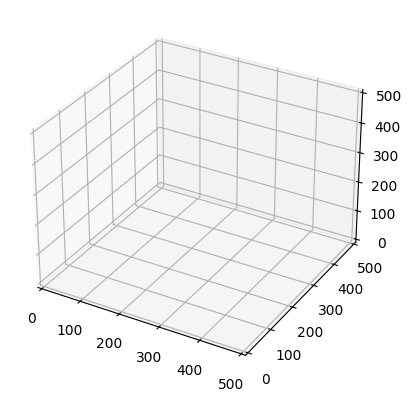

In [2]:
fig = plt.figure()
ax = plt.axes(projection='3d')

chains = []

for i in range(0, 300, 20):
    positions = get_pos_of_resn(i)
    chains.append(positions)

    ax.plot3D(positions[:, 0], positions[:, 1], positions[:, 2], alpha=.5)

ax.axes.set_xlim3d([0, 500])
ax.axes.set_ylim3d([0, 500])
ax.axes.set_zlim3d([0, 500])

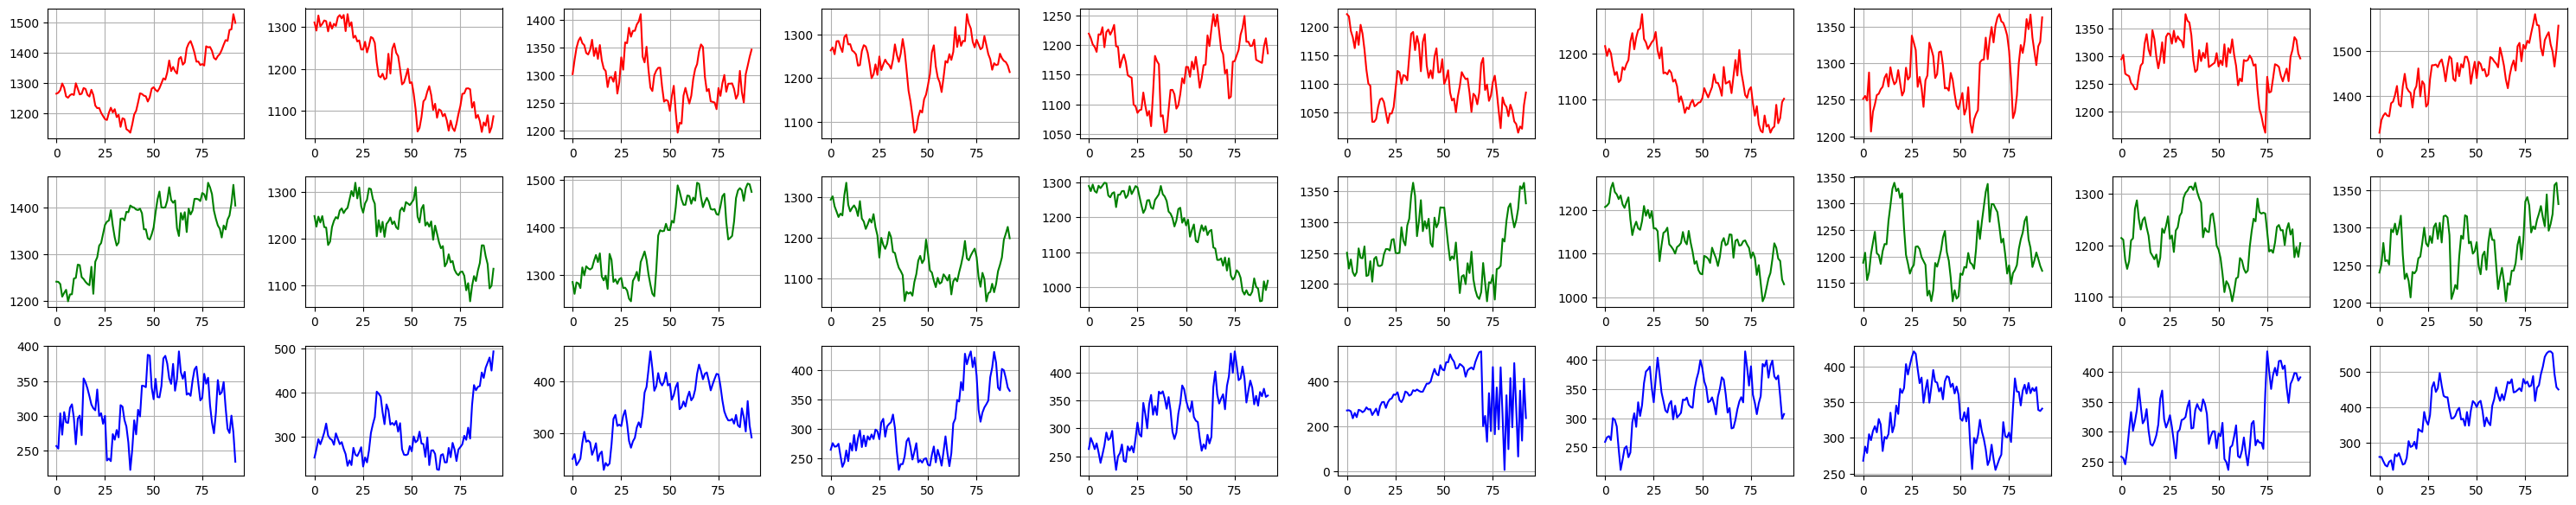

In [ ]:
import matplotlib.pyplot as plt

plt.ion()
fig, axs = plt.subplots(3, 10, figsize=(30, 6))
fig.tight_layout()

while True:
    for i in range(10):
        positions = get_pos_of_resn(219 * (i + 1) - 1)
        colors = ["red", "green", "blue"]

        axs[2, i].axhline(230)
        for j in range(3):
            axs[j, i].clear() # Clear the previous frame
            axs[j, i].plot(positions[:, j], color=colors[j])
            axs[j, i].grid()
            
            # The axhline needs to be redrawn if that specific axis was cleared


    fig.canvas.draw()
    fig.canvas.flush_events()
    plt.pause(1.5)